In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q1. This question provides some practice cleaning variables which have common problems.**

1. Numeric variable: For airbnb_NYC.csv, clean the Price variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

I end up having 0 missing values for Price.


2. Categorical variable: For the Minnesota police use of for data, mn_police_use_of_force.csv, clean the subject_injury variable, handling the NA's; this gives a value Yes when a person was injured by police, and No when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned subject_injury variable with the force_type variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the np.nan/None values with the label Missing.

The proportion of values that are missing is 76.19%. The patterns regarding the data that is missing is not random. It is concentrated in Bodyily Force and Chemical Irritant. There are some that are completly missing data like Less Lethal Force, which suggests that injuries may only be recorded when physical contact meets a certain bar.


3. Dummy variable: For metabric.csv, convert the Overall Survival Status variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.


4. Missing values: For airbnb_NYC.csv, determine how many missing values of Review Scores Rating there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

There are 8,323 missing values. The median score used is 94.0 and this might negatively impact the results by creating variance reduction and selection bias. For variance reduction, it stacks the observations at the same value and cause overconfident statistical tests. In terms of selection bias, the missing reviews are not missing at random. IN many cases, there might be listings that may have poor experiences that do not have ratings yet. Giving them a 94 would overestimate the quality of those properties and bias the dataset.

In [ ]:
import pandas as pd
import numpy as np
airbnb = pd.read_csv('airbnb_hw.csv')

airbnb['Price_Cleaned'] = pd.to_numeric(
    airbnb['Price'].astype(str).str.replace('$', '').str.replace(',', ''),
    errors='coerce'
)

missing_price = airbnb['Price_Cleaned'].isna().sum()
print(f"Missing values in Price: {missing_price}")

Missing values in Price: 0


In [ ]:
police = pd.read_csv('mn_police_use_of_force.csv')

prop_missing = police['subject_injury'].isna().mean()
print(f"Proportion of missing injury data: {prop_missing:.2%}")

missing_pattern = pd.crosstab(police['force_type'], police['subject_injury'].isna())
print(missing_pattern)

police['subject_injury'] = police['subject_injury'].fillna('Missing')

final_ct = pd.crosstab(police['subject_injury'], police['force_type'])

Proportion of missing injury data: 76.19%
subject_injury               False  True 
force_type                               
Baton                            2      2
Bodily Force                  2379   7051
Chemical Irritant              172   1421
Firearm                          2      0
Gun Point Display               77     27
Improvised Weapon               74     74
Less Lethal                      0     87
Less Lethal Projectile           3      0
Maximal Restraint Technique      0    170
Police K9 Bite                  46     31
Taser                          322    985


In [ ]:
import pandas as pd

metabric = pd.read_csv("data/metabric.csv")
metabric.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [ ]:
metabric["Overall Survival Status"].unique()

array(['0:LIVING', '1:DECEASED'], dtype=object)

In [ ]:
metabric["survival_dummy"] = metabric["Overall Survival Status"].map({
    "0:LIVING": 1,
    "1:DECEASED": 0
})

In [ ]:
metabric[["Overall Survival Status", "survival_dummy"]].head()
metabric["survival_dummy"].value_counts()

,count
survival_dummy,
0,768
1,575


In [ ]:
missing_reviews = airbnb['Review Scores Rating'].isna().sum()
print(f"Missing Review Scores: {missing_reviews}")

median_rating = airbnb['Review Scores Rating'].median()
airbnb['Review_Scores_Imputed'] = airbnb['Review Scores Rating'].fillna(median_rating)

Missing Review Scores: 8323


**Q2. Go to https://sharkattackfile.net/ and download their dataset on shark attacks.**

1. Open the shark attack file using Pandas. It is probably not a csv file, so read_csv won't work. What does work?


Because the file is in a .xls format, and Pandas has a dedicated reader for spreadsheet files, we would use read_excel() instead of read_csv().


2. Drop any columns that do not contain data.


3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.


An observation is a single recorded incident of a shark and human interaction. It affects my choice in cleaning and analyzing the data by handling duplicate events very carefully. For example, you could have 2 people getting bit at the same time by the same shark. The dataset would probably list the two as two seperate observations or just one event. So it is important to distinguish whether or not we are assessing the amount of shark bites or the amount of victims. We also have to delete rows with missing data and empy observations.


4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?


After some filtering, I see that the range of years goes from 1940 to 2026. Attacks seem to be increasing over time. I think I'd attribute this to better reporting techniques and marine technology instead of more aggressive shark behavior.


5. Clean the Age variable and make a histogram of the ages of the victims.


6. Clean the Type variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

The proportion of attacks that are unprovoked is 73.88%

7. Clean the Fatal Y/N variable so it only takes three values: Y, N, and Unknown.


8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

An attack is less likely to be fatal if it is provoked. Provoked means that a human bothered the shark. In a sense, the shark is acting in defense because the shark isn't trying to actively eat the human. One can assume because of this, the bites are less severe and not fatal.



In [ ]:
import pandas as pd

df = pd.read_excel("GSAF5.xls")

In [ ]:
df.dropna(axis=1, how='all', inplace=True)

In [ ]:
pd.to_numeric(df['Year'], errors='coerce')

,Year
0,2026.0
1,2026.0
2,2026.0
3,2026.0
4,2026.0
...,...
7069,0.0
7070,0.0
7071,0.0
7072,0.0


In [ ]:
df[df['Year'] >= 1940]

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5535,1940,1940.0,Unprovoked,NEW GUINEA,Bwagaoia,"Bagalina, North coast Misima Island",NaN,small girl,F,NaN,...,NaN,"A. Bleakley; A. M. Rapson, p.148",1940.00.00.e-small-girl.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.e,1940.00.00.e,1535.0,NaN,NaN
5536,1940,1940.0,Unprovoked,PAPUA NEW GUINEA,Western Papuan Gulf,Kerema,male,a native,NaN,NaN,...,NaN,"Papuan Villager, 11/1940",1940.00.00.d-Kerema.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.d,1940.00.00.d,1534.0,NaN,NaN
5537,1940,1940.0,Invalid,SOUTH AFRICA,Eastern Cape Province,Kidd's Beach,Swimming,NaN,NaN,NaN,...,Questionable incident,"D. Davies, p. 102",1940.00.00.c-KiddsBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.c,1940.00.00.c,1533.0,NaN,NaN
5538,1940,1940.0,Invalid,SOUTH AFRICA,KwaZulu-Natal,Winkelspruit,NaN,Indian female,F,NaN,...,Questionable incident,"V.M. Coppleson (1958), p.247; SAF Case #161. U...",1940.00.00.b-IndianFemale.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1940.00.00.b,1940.00.00.b,1532.0,NaN,NaN


In [ ]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_since_1940 = df[df['Year'] >= 1940]
print(df_since_1940['Year'].value_counts().sort_index())

Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     66
2026.0     12
Name: count, Length: 87, dtype: int64


<Axes: >

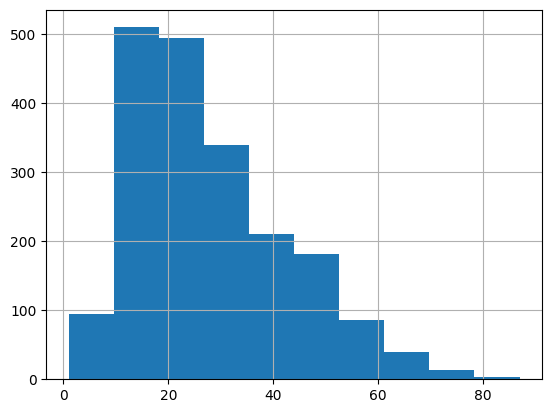

In [ ]:
df['Age'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
df['Age'].hist()

In [ ]:
def clean_type(t):
    t = str(t).strip().capitalize()
    if 'Unprovoked' in t:
        return 'Unprovoked'
    elif 'Provoked' in t:
        return 'Provoked'
    else:
        return 'Unknown'

df['Type'] = df['Type'].apply(clean_type)

proportion = (df['Type'] == 'Unprovoked').mean()
print(f"Proportion of unprovoked attacks: {proportion:.2%}")

Proportion of unprovoked attacks: 73.88%


In [ ]:
def clean_fatal(f):
    f = str(f).strip().upper()
    if f == 'Y':
        return 'Y'
    elif f == 'N':
        return 'N'
    else:
        return 'Unknown'

df['Fatal Y/N'] = df['Fatal Y/N'].apply(clean_fatal)

In [ ]:
pd.crosstab(df['Type'], df['Fatal Y/N'], normalize='index')

Fatal Y/N,N,Unknown,Y
Type,,,
Provoked,0.953416,0.013975,0.032609
Unknown,0.372924,0.460963,0.166113
Unprovoked,0.742250,0.015117,0.242633


**Q3. Open the "tidy_data.pdf" document available in https://github.com/ds4e/wrangling, which is a paper called Tidy Data by Hadley Wickham.**

1. Read the abstract. What is this paper about?

The paper focuses on data tidying, which is an important part of data cleaning. It creates a framework and structure for datasets. Each variable is a column and each observation is a row. This makes it easy for you to take the data and model and visualize it. You can also use data analysis tools that can work together with the data to find solutions.

2. Read the introduction. What is the "tidy data standard" intended to accomplish?

The tidy data standard is intended to accomplish providng a way to organize data within a dataset, open doors to data exploraiton and analysis, make data cleaning easier through a framework, make the creation of data analysis tools that work well, and allow the user to focus on actual problems and not the data logistics.


3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."

For the 1st quotation, this sentence means that while all tidy datasets follow the same structure, there isn't a structure for messy data. Messy data can be arranged and manipulated in tons of ways, including non-standard ways.

For the 2nd quotation, this means that analysts can identify variables and observations for specific datasets, but creating a universal definition that appies to all data is quite difficult. For example, phone numbers and defining whether they are work or home values can change depending on the analysis' goals.

4. Read Section 2.2. How does Wickham define values, variables, and observations?

Wickham defines values as individual pieces of data, like numbers and strings, that make up a dataset.

Wickham defines variables as a variable that contains all values that measure the same attribute across units.

Wickham defines observations as containing all values measured on the same unit but across different attributes.

5. How is "Tidy Data" defined in section 2.3?

Tidy Data is defined as the standard way of mapping the meaning of a dataset to its actual structure.

6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?

The 5 most common problems with messy datasets are that 1) column headers are values, not variable names, 2) multiple variables are stored in one column, 3) variables are stored in both rows and columns, 4) multiple types of observational units are stored in the same table, 5) a single observational unit is stored in multiple tables. The data in table 4 is messy because the column headers are values of the income varibale, rather than the variable names themselves.
Melting in a dataset is the process of turning columns into rows to tidy a dataset. You basically take columns that are no variables and convert them into new variables.  

7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

Table 11 is messy because it has variables spread across columns and the element column is not a variable but actually ocntains the names of variables. Table 12 is tidy and molten because it is unpivoted so that the days are not longer than the separate columns. In the tidy form, each row represents a single day's observations and each column represents a single measured variable, which makes it easy to analyze.

**Q4. This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?**

For this question, .groupby([vars]).count() and .groupby([vars]).sum() will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the ForeignGifts_edu.csv dataset.


2. For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.

The distribution of foreign gift amounts is heavily skewed to the right. There are a lot of small gifts and a small number of large transfers. The mean is much larger than the median. This basically means that large gifts raise the average.


3. For Gift Type, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

Contracts make up the largest proportion of transfers at 61.2%. This is followed up by Monetary gifts at 38.75% and then Real estate at a very small percentage.

4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

The top 15 countries by number of gifts is the first plot. The top 15 countries by total amount given is the second plot.

5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.

The top 15 institutions are listed in the table produced.


6. Which giftors provide the most money, in total?

The top 5 giftors that provide the most money in total are Qatar Foundation, Qatar National Res, Qatar Foundation for Education, Anonymous, and
Saudi Arabian Cultural Mission.




In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gifts = pd.read_csv("data/ForeignGifts_edu.csv")
gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


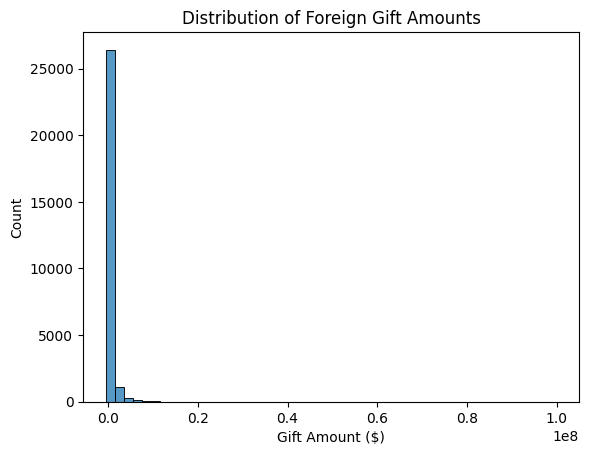

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


In [ ]:
sns.histplot(gifts["Foreign Gift Amount"], bins=50)
plt.title("Distribution of Foreign Gift Amounts")
plt.xlabel("Gift Amount ($)")
plt.show()

gifts["Foreign Gift Amount"].describe()

In [ ]:
gift_type_counts = gifts["Gift Type"].value_counts()
gift_type_props = gifts["Gift Type"].value_counts(normalize=True)

gift_type_counts
gift_type_props

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [ ]:
top_countries_count = (
    gifts.groupby("Country of Giftor")
         .size()
         .sort_values(ascending=False)
         .head(15)
)

top_countries_count


,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [ ]:
top_countries_amount = (
    gifts.groupby("Country of Giftor")["Foreign Gift Amount"]
         .sum()
         .sort_values(ascending=False)
         .head(15)
)

top_countries_amount


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [ ]:
top_institutions = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
         .sum()
         .sort_values(ascending=False)
         .head(15)
)

top_institutions

,Foreign Gift Amount
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


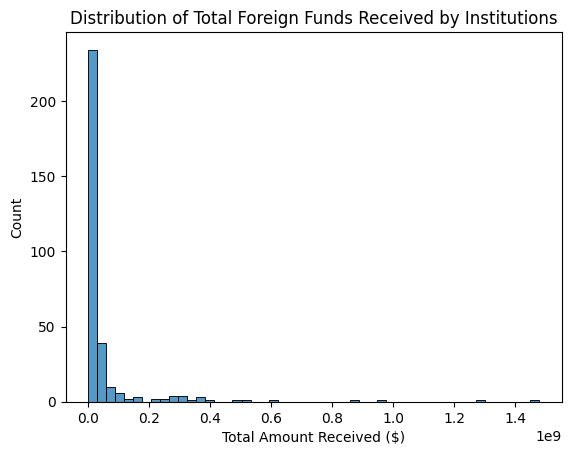

In [ ]:
institution_totals = gifts.groupby("Institution Name")["Foreign Gift Amount"].sum()

sns.histplot(institution_totals, bins=50)
plt.title("Distribution of Total Foreign Funds Received by Institutions")
plt.xlabel("Total Amount Received ($)")
plt.show()

In [ ]:
top_giftors = (
    gifts.groupby("Giftor Name")["Foreign Gift Amount"]
         .sum()
         .sort_values(ascending=False)
         .head(15)
)

top_giftors

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497



**Q5. This question provides some practice doing exploratory data analysis and visualization.**

We'll use the college_completion.csv dataset from the US Department of Education. The "relevant" variables for this question are:

level - Level of institution (4-year, 2-year)
aid_value - The average amount of student aid going to undergraduate recipients
control - Public, Private not-for-profit, Private for-profit
grad_100_value - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)


1. Load the college_completion.csv data with Pandas.


2. How many observations and variables are in the data? Use .head() to examine the first few rows of data.

The dataset contains 3,789 observations and 63 variables.

3. Cross tabulate control and level. Describe the patterns you see in words.

The pattern that I see is that public institutions are mostly 2-ear colleges, private not for profit schools are almost all 4 year colleges, and private for profit schools are a bit more split even between 2 year and 4 year levels.

4. For grad_100_value, create a kernel density plot and describe table. Now condition on control, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?

The Kernal Density plot shows a right skewed graph meaning that most institutions have lower on time graduation rates.
For the condition on control,
Private not for profit schools have the most favorable graduation rate with 41.66% as the mean which is higher than public at 17.43% and private for profit at 29.11%. The public curve is tall and narrow on the left, which indicates that the majority of public schools have very low on time graduation rates. Private not for profit institutions have the most favorable graduation rates.

5. Make a scatterplot of grad_100_value by aid_value, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on control. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

The scatterplot shows a positive linear trend. The correlation is positive, which means as the average student aid increases, the graduation rate usually increases.
For the conditioning on control plot, the in private not for profit schools have points that cluster around an upward sloping line. There is a return on investment when higher aid leads to higher success. Aid varies most positively with graduation rates for Private not for profit institutions.



In [ ]:
import pandas as pd
df = pd.read_csv('college_completion.csv')

In [ ]:
print(df.shape)
print(df.head())

(3798, 63)
   index  unitid                            chronname        city    state  \
0      0  100654               Alabama A&M University      Normal  Alabama   
1      1  100663  University of Alabama at Birmingham  Birmingham  Alabama   
2      2  100690                   Amridge University  Montgomery  Alabama   
3      3  100706  University of Alabama at Huntsville  Huntsville  Alabama   
4      4  100724             Alabama State University  Montgomery  Alabama   

    level                 control  \
0  4-year                  Public   
1  4-year                  Public   
2  4-year  Private not-for-profit   
3  4-year                  Public   
4  4-year                  Public   

                                               basic hbcu flagship  ...  \
0  Masters Colleges and Universities--larger prog...    X      NaN  ...   
1  Research Universities--very high research acti...  NaN      NaN  ...   
2            Baccalaureate Colleges--Arts & Sciences  NaN      NaN  ... 

In [ ]:
ct = pd.crosstab(df['control'], df['level'])
print(ct)

level                   2-year  4-year
control                               
Private for-profit         465     527
Private not-for-profit      68    1180
Public                     926     632


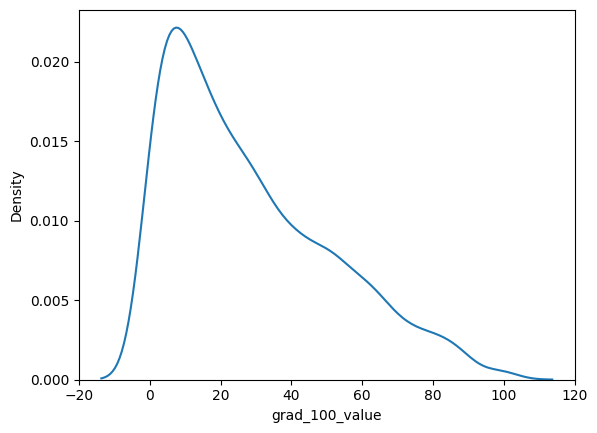

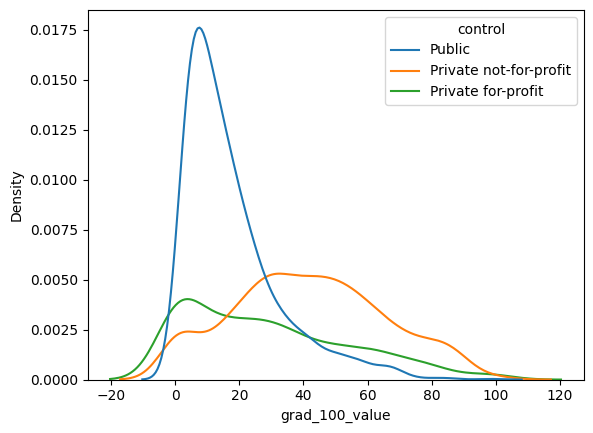

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['grad_100_value'].dropna())
plt.show()

sns.kdeplot(data=df, x='grad_100_value', hue='control')
plt.show()

<Axes: xlabel='aid_value', ylabel='grad_100_value'>

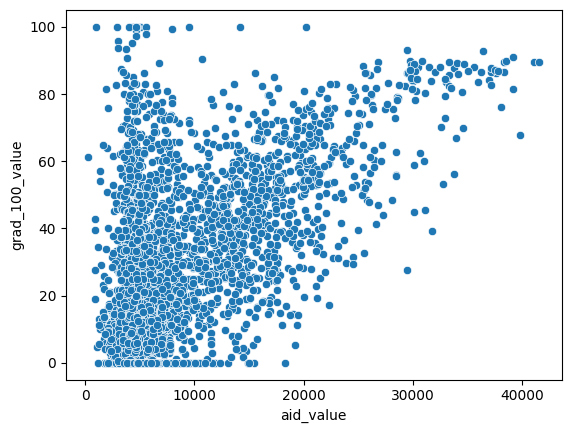

In [ ]:
correlation = df['grad_100_value'].corr(df['aid_value'])

sns.scatterplot(data=df, x='aid_value', y='grad_100_value')

**Q6**

**Uploaded Photo of my solutions to GitHub**


**Q7. This question provides some practice doing exploratory data analysis and visualization.**

We'll use the ames_prices.csv dataset. The "relevant" variables for this question are:

price - Sale price value of the house
Bldg.Type - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)
1. Load the college_completion.csv data with Pandas.


2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use .groupby() to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?

The price distribution is skewed to the right, which basically means that most homes sell at a moderate price and a small number of expensive homes create the upper tail. This table shows how the mean is higher than the median. Single family homes have the highest average sale prices. They also have the largest standard deviation, which means they have the greatest variability in prices. Duplexes and townhomes seem to be cheaper and more clustered.

3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).



4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?

Yes, there are some outliers. They are the points that are above the whiskers. Single family homes have the highest medians and some of the most extreme outliers. Townhoms and multi-family homes show lower means and more clustered data.

5. Make a dummy variable indicating that an observation is an outlier.

A home is an outlier if its price is more than 1.5 IQRs below Q1 or above Q3.

6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

Winsorizing the price variable reduces the influence of extreme values. It does this by capping the top 1% and the bottom 1% of prices. The distribution becomes less skewed and we see the standard deviation also decrease. The maximum value is also lower. This basically takes out luxury outliers and gives us a better idea of a typical housing market.

In [ ]:
import pandas as pd

ames = pd.read_csv("data/ames_prices.csv")
college = pd.read_csv("data/college_completion.csv")

ames.head()
college.head()


,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


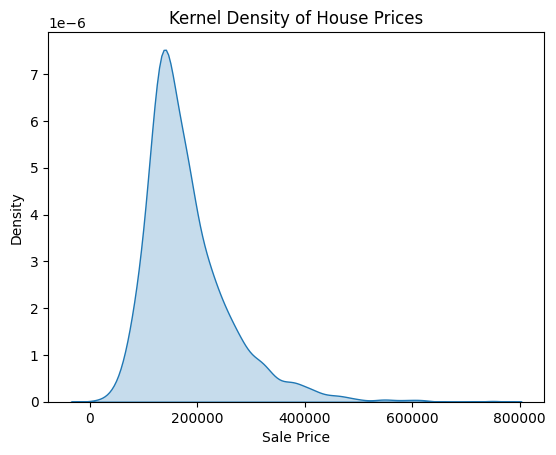

,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(ames["price"], fill=True)
plt.title("Kernel Density of House Prices")
plt.xlabel("Sale Price")
plt.show()

ames["price"].describe()

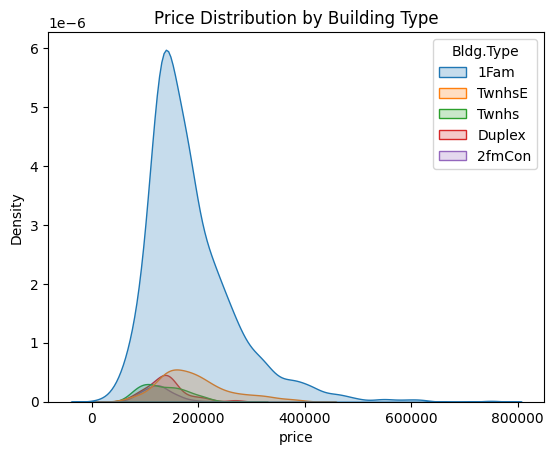

,price
Bldg.Type,
1Fam,82821.802329
TwnhsE,66191.738021
Twnhs,41938.931130
Duplex,39498.973534
2fmCon,31089.239840


In [ ]:
sns.kdeplot(data=ames, x="price", hue="Bldg.Type", fill=True)
plt.title("Price Distribution by Building Type")
plt.show()

ames.groupby("Bldg.Type")["price"].describe()
ames.groupby("Bldg.Type")["price"].mean().sort_values(ascending=False)
ames.groupby("Bldg.Type")["price"].std().sort_values(ascending=False)

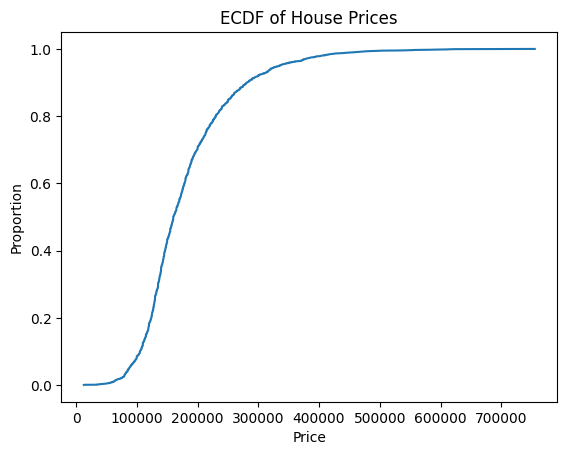

array([ 12789., 129500., 160000., 213500., 755000.])

In [ ]:
from statsmodels.distributions.empirical_distribution import ECDF
import numpy as np

ecdf = ECDF(ames["price"])
plt.plot(ecdf.x, ecdf.y)
plt.title("ECDF of House Prices")
plt.xlabel("Price")
plt.ylabel("Proportion")
plt.show()

np.percentile(ames["price"], [0, 25, 50, 75, 100])


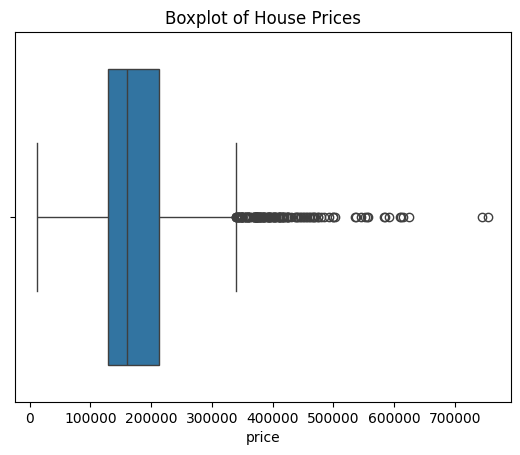

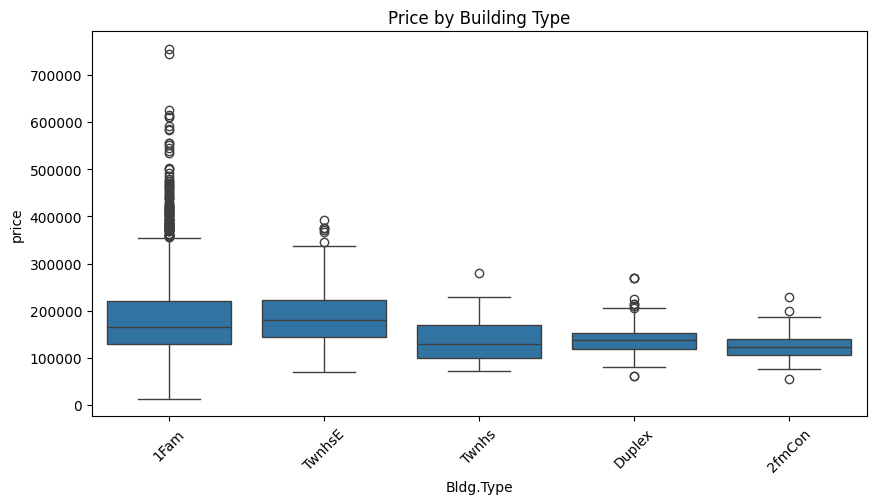

In [ ]:
sns.boxplot(x=ames["price"])
plt.title("Boxplot of House Prices")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=ames, x="Bldg.Type", y="price")
plt.xticks(rotation=45)
plt.title("Price by Building Type")
plt.show()

In [ ]:
Q1 = ames["price"].quantile(0.25)
Q3 = ames["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

ames["outlier"] = ((ames["price"] < lower) | (ames["price"] > upper)).astype(int)

ames["outlier"].value_counts()


,count
outlier,
0,2793
1,137


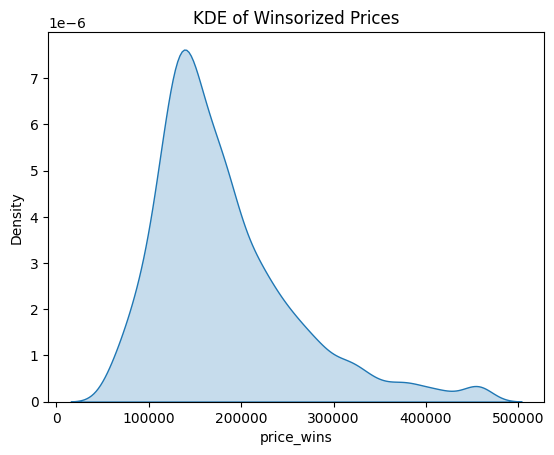

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,price_wins
count,2930.000000
mean,180095.501365
std,75872.123444
min,61500.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,457347.000000


In [ ]:
from scipy.stats.mstats import winsorize

ames["price_wins"] = winsorize(ames["price"], limits=[0.01, 0.01])

sns.kdeplot(ames["price_wins"], fill=True)
plt.title("KDE of Winsorized Prices")
plt.show()

ames["price_wins"].describe()